In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch

##### Define Which Function to Test

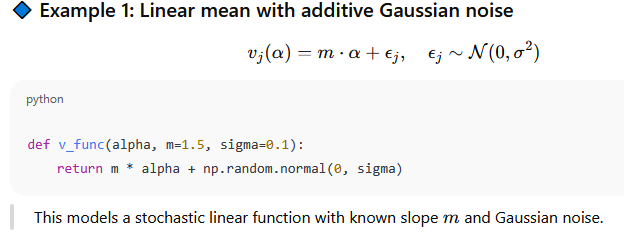

In [2]:
def v_func_Gaus(alpha, m=1.5, sigma=0.1):
    return m * alpha + np.random.normal(0, sigma)

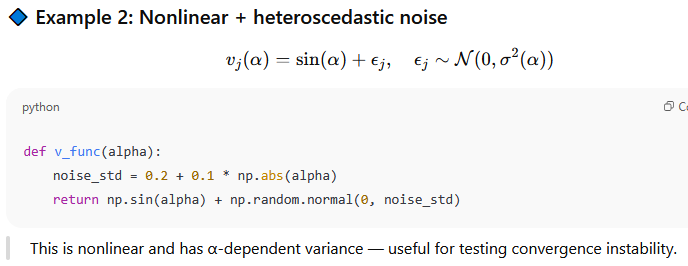

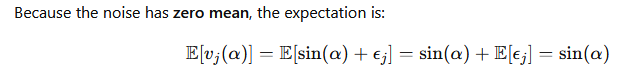

In [3]:
def v_func_NL(alpha):
    noise_std = 0.2 + 0.1 * np.abs(alpha)
    return np.sin(alpha) + np.random.normal(0, noise_std)

This function has no globally uniform expectation function, and may cause unpredictable convergence.

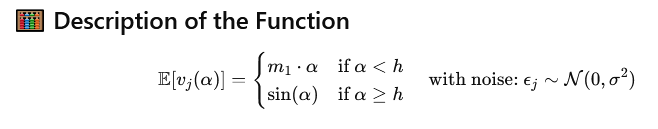

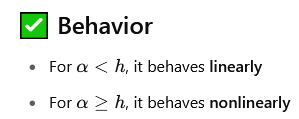

In [2]:
def sample_v_func_NU(alpha: float, n: int, m1: float = 1.0, h: float = 8.0, sigma: float = 0.1) -> torch.Tensor:
    """
    PyTorch-compatible stochastic function with piecewise expectation.
    This function has no globally uniform expectation function, and may cause unpredictable convergence.

    PyTorch-compatible stochastic function with piecewise expectation:
    E[v_j(α)] = -(α - 5)^2 + 6 for α < h
    E[v_j(α)] = m1*α - 11 for α ≥ h

    Parameters:
        alpha : float       # Current parameter value
        m1    : float       # Linear slope in region α > h
        h     : float       # Breakpoint separating regions
        sigma : float       # Standard deviation of Gaussian noise

    Returns:
        v_j : torch.Tensor  # One sample from v_j(α)
    """
    alpha_tensor = torch.tensor(alpha, dtype=torch.float32)    # ensure it's a float

    if alpha < h:
        mean = -((alpha_tensor - 5) ** 2) + 6
    else:
        mean = m1*alpha_tensor - 11
    
    noise = torch.normal(mean=0.0, std=sigma, size=(n,))
    samples = mean + noise  # broadcasting scalar mean over n noise samples
    return samples  # Return a tensor of a batch of n stochastic samples with torch.Size([1000]). Each sample is: vj​(α) = mean(α) + Gaussian noise

##### Define the Variables Initially

In [3]:
alpha = 1.0  # α: current parameter value (float)
v_d  = 7.0  # v_d: target value (float)
n_ini = 1000  # n_ini: initial number of samples per iteration (int)
lamb = 0.1  # λ: variance penalty weight (float)
gamma = 0.01  # γ: learning rate (float)
ep_tol = 1e-8  # ε: small constant for numerical stability and tolerance (float)
h = 0.1  # h: probing step size for finite difference (float)

In [4]:
n = 1000000
v1 = sample_v_func_NU(alpha=alpha, n=n)  # Sample from linear region

##### Systemic Function Calculation Class Notes

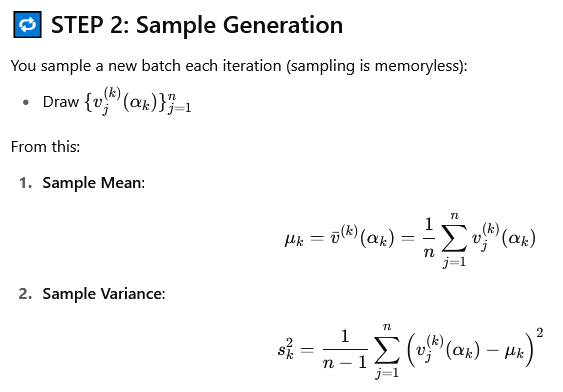

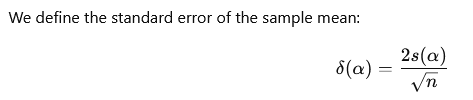

##### Systemic Function Class

In [32]:
class MacroStats:
    def __init__(self, epsilon=1e-8, slope_tol=0.01, stderr_tol=2.0):
        # Store records as list of dicts with each α and its statistics
        self.records = []  # Each item: {"alpha": α, "mu": μ, "var": s², "stderr": δ}
        # Store Polyak–Ruppert slope history as torch tensor list
        self.slope_history = []  # list of torch scalars
        # Parameters for stability, tolerance, confidence
        self.epsilon = epsilon                    # numerical stability (denominator guard)
        self.slope_tol = slope_tol                # convergence threshold for m_k
        self.stderr_tol = stderr_tol              # multiplier for stderr-based agreement
        # Most recent slope estimate
        self.m_k = None  ## type: torch.Tensor or None

    def macro_observations(self, alpha: float, samples: torch.Tensor):
        """
        Register a new observation (α, {v_j(α)}), and compute macroscopic statistics.
        Given:
            - α: The current parameter value
            - {v_j(α)}: A batch of n sampled stochastic values at α
        Computes:
            - Sample mean:
                μ(α) ≈ (1/n) ∑_{j=1}^n v_j(α)
            - Sample variance (unbiased estimator):
                s²(α) ≈ (1 / (n - 1)) ∑_{j=1}^n (v_j(α) - μ(α))²
            - Approximate standard error bound (95% confidence):
                This is a confidence bound, based on the approximation that ~95% of sample means (if resampled many times) fall within this range under the Central Limit Theorem as:
                μ ± 2⋅SE(α)
                δ(α) ≈ (2s(α)) / √n
        Stores:
            {"alpha": α, "mu": μ, "var": s², "stderr": δ} as a dict in self.records
        Returns:
            - μ(α), s²(α), δ(α)
        """
        mu = samples.mean() # Sample mean.
        var = samples.var(unbiased=True) # Sample variance.
        std = torch.sqrt(var) # Sample standard deviation.
        stderr_ci = 2 * std / torch.sqrt(torch.tensor(len(samples), dtype=torch.float32)) # Standard error bound (95% CI).

        
        # Create the record as a dict of torch scalars
        record = {
            "alpha": torch.tensor(alpha, dtype=torch.float32),
            "n": len(samples),
            "mu": mu,
            "var": var,
            "std": std,
            "stderr_ci": stderr_ci
        }
        # Update the record within the function.
        self.records.append(record)
        return record  # Optionally return information for inspection.
    
    def suggest_step_size(self, alpha: float, d: int = 1, kappa: float = 1.0, min_h: float = 1e-3) -> float:
        """
        Suggest a finite difference step size h for probing μ(α), based on an unscented transform principle.

        The step size is computed as:
            h = sqrt(d + κ) ⋅ σ_α
        where:
            - d is the dimensionality of the input (default 1),
            - κ is a spread control parameter (commonly in [0, 3]),
            - σ_α is the estimated standard deviation of the input parameter α.
        Since σ_α is not directly known, it is approximated from the observed output variance
        as:
            σ_α ≈ s(α) / √n
        where s(α) is the sample standard deviation of {v_j(α)}, and n is the sample size.
        Now, the step size is computed as:
            h ≈ sqrt(d + κ) ⋅ s(α) / √n
        Parameters:
            - alpha (float): The parameter location α to retrieve step size for.
            - d (int): Dimension of α, (default 1).
            - kappa (float): Spread parameter controlling sigma point scaling, (default 1.0).
            - min_h (float): Floor value to prevent degenerately small step size, (default 1e-3).
        Returns:
            - h (float): Recommended probing step size for finite difference or sigma point generation
        """
        # Specified alpha.
        alpha_tensor = torch.tensor(alpha, dtype=torch.float32)
        # Search for matching α
        match = next((r for r in self.records if torch.isclose(r["alpha"], alpha_tensor, atol=1e-6)), None)
        if match is None:
            raise ValueError(f"No statistics found for α = {alpha} in recorded macroscopic observations.")

        s = match["std"]  # Sample standard deviation of v_j(α).
        n = match["n"]  # Sample size at this α (Python int).

        sigma_alpha = s / torch.sqrt(torch.tensor(n, dtype=torch.float32))
        h = torch.sqrt(torch.tensor(d + kappa, dtype=torch.float32)) * sigma_alpha
        h = torch.maximum(h, torch.tensor(min_h))
        print(f"h = {h}, min_h = {min_h}")
        return h.item()

##### Plotting Macro Functions and Test Function

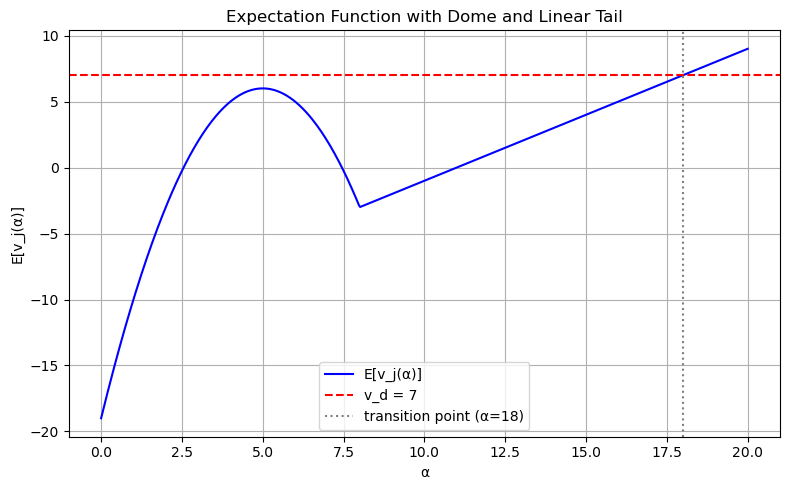

In [9]:
def expected_v_np(alpha):
    return np.where(
        alpha < 8,
        -(alpha - 5) ** 2 + 6,
        alpha - 11
    )

alpha_vals = np.linspace(0, 20, 600)
expectation_vals = expected_v_np(alpha_vals)

plt.figure(figsize=(8, 5))
plt.plot(alpha_vals, expectation_vals, label="E[v_j(α)]", color="blue")
plt.axhline(y=7, color="red", linestyle="--", label="v_d = 7")
intersect = 18
plt.axvline(x=intersect, color="gray", linestyle=":", label=f"transition point (α={intersect})")
plt.title("Expectation Function with Dome and Linear Tail")
plt.xlabel("α")
plt.ylabel("E[v_j(α)]")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [33]:
# Instantiate the MacroStats class
stats = MacroStats()

In [34]:
# Define sampling parameters
alphas = list(range(0, 22, 1))  # α = 0, 1, ...
n = 1000000
# Collect macro observations for each α
for α in alphas:
    samples = sample_v_func_NU(alpha=α, n=n)
    stats.macro_observations(alpha=α, samples=samples)

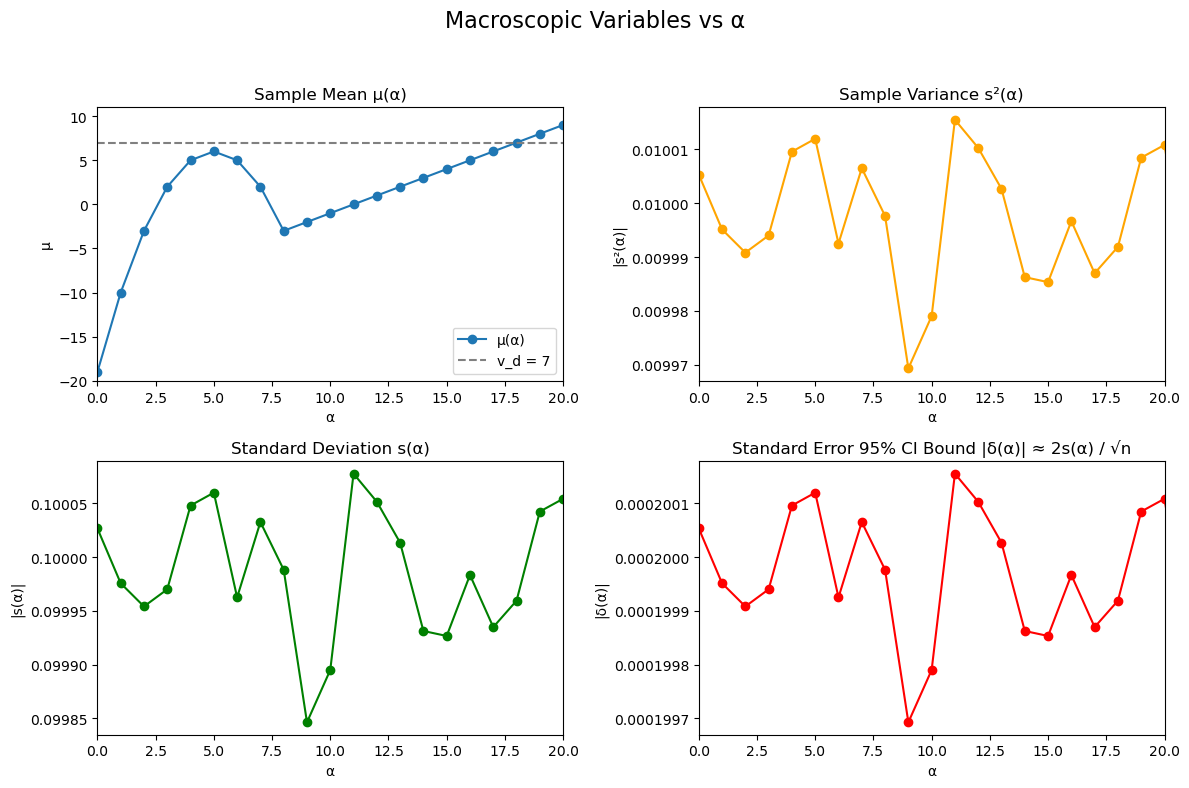

In [36]:
# Extract data from records
alphas = [r["alpha"].item() for r in stats.records]
mus    = [r["mu"].item()     for r in stats.records]
vars_  = [r["var"].item()    for r in stats.records]
stds   = [r["std"].item()    for r in stats.records]
stderrs= [r["stderr_ci"].item() for r in stats.records]

# Define v_d for reference
v_d = 7.0

# Create 2x2 plot
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Macroscopic Variables vs α", fontsize=16)

# Plot 1: μ(α)
axs[0, 0].plot(alphas, mus, marker='o', label='μ(α)')
axs[0, 0].axhline(v_d, color='gray', linestyle='--', label='v_d = 7')
axs[0, 0].set_title("Sample Mean μ(α)")
axs[0, 0].set_xlabel("α")
axs[0, 0].set_ylabel("μ")
axs[0, 0].legend()
axs[0, 0].set_xlim([0, 20])            # Domain
axs[0, 0].set_ylim([min(mus) - 1, max(mus) + 1])  # Range with padding

# Plot 2: s²(α)
axs[0, 1].plot(alphas, vars_, marker='o', color='orange')
axs[0, 1].set_title("Sample Variance s²(α)")
axs[0, 1].set_xlabel("α")
axs[0, 1].set_ylabel("|s²(α)|")
axs[0, 1].set_xlim([0, 20])
# axs[0, 1].set_ylim([min(vars_) - 0.01, max(vars_) + 0.01])

# Plot 3: s(α)
axs[1, 0].plot(alphas, stds, marker='o', color='green')
axs[1, 0].set_title("Standard Deviation s(α)")
axs[1, 0].set_xlabel("α")
axs[1, 0].set_ylabel("|s(α)|")
axs[1, 0].set_xlim([0, 20])
# axs[1, 0].set_ylim([min(stds) - 0.01, max(stds) + 0.01])

# Plot 4: δ(α)
axs[1, 1].plot(alphas, stderrs, marker='o', color='red')
axs[1, 1].set_title("Standard Error 95% CI Bound |δ(α)| ≈ 2s(α) / √n")
axs[1, 1].set_xlabel("α")
axs[1, 1].set_ylabel("|δ(α)|")
axs[1, 1].set_xlim([0, 20])
# axs[1, 1].set_ylim([min(stderrs) - 0.001, max(stderrs) + 0.001])

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [35]:
print(stats.suggest_step_size(alpha=stats.records[1]['alpha'], d = 1, kappa = 3.0, min_h = 1e-3))

h = 0.0010000000474974513, min_h = 0.001
0.0010000000474974513


C:\Users\Mike\AppData\Local\Temp\ipykernel_20912\3838375761.py:78: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  alpha_tensor = torch.tensor(alpha, dtype=torch.float32)


##### Step Size Notes

Choose a finite-difference step size h for probing μ(α), large enough that the estimated change in μ is detectable above sample noise, but not so large that it moves into unrelated nonlinear regions.

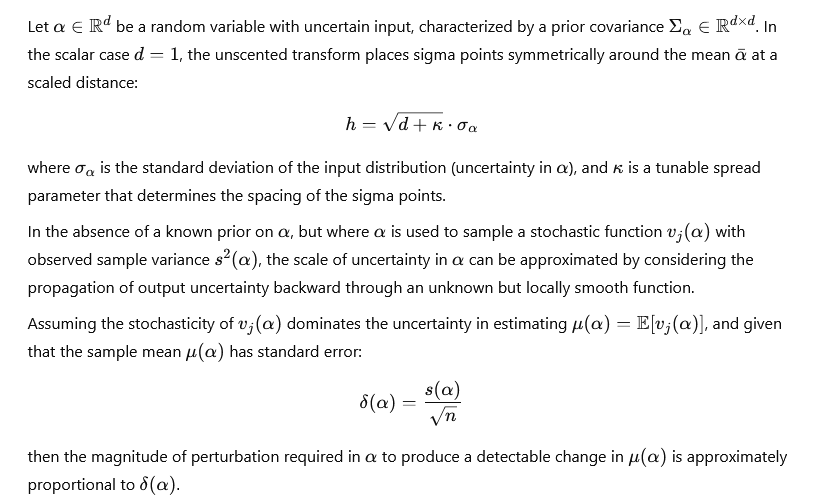

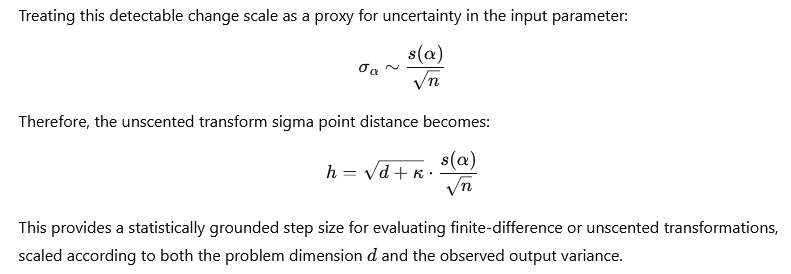

In [ ]:
def suggest_step_size(self, d: int = 1, kappa: float = 1.0, min_h: float = 1e-3) -> float:
    """
    Suggest a finite difference step size h for probing μ(α), based on an unscented transform principle.

    The step size is computed as:
        h = sqrt(d + κ) ⋅ σ_α
    where:
        - d is the dimensionality of the input (default 1),
        - κ is a spread control parameter (commonly in [0, 3]),
        - σ_α is the estimated standard deviation of the input parameter α.
    Since σ_α is not directly known, it is approximated from the observed output variance
    as:
        σ_α ≈ s(α) / √n
    where s(α) is the sample standard deviation of {v_j(α)}, and n is the sample size.
    Now, the step size is computed as:
        h ≈ sqrt(d + κ) ⋅ s(α) / √n
    Parameters:
        - d (int): Dimension of α, (default 1)
        - kappa (float): Spread parameter controlling sigma point scaling, (default 1.0).
        - min_h (float): Floor value to prevent degenerately small step size, (default 1e-3).
    Returns:
        - h (float): Recommended probing step size for finite difference or sigma point generation
    """
    if not self.records:
        raise ValueError("No macroscopic records available to base step size on.")

    latest = self.records[-1]
    s = latest["std"]  # Sample standard deviation of v_j(α).
    n = latest["n"]  # Sample size at this α (Python int).

    sigma_alpha = s / torch.sqrt(torch.tensor(n, dtype=torch.float32))
    h = torch.sqrt(torch.tensor(d + kappa, dtype=torch.float32)) * sigma_alpha
    h = torch.maximum(h, torch.tensor(min_h))
    return h.item()


##### Finite Difference Calculations

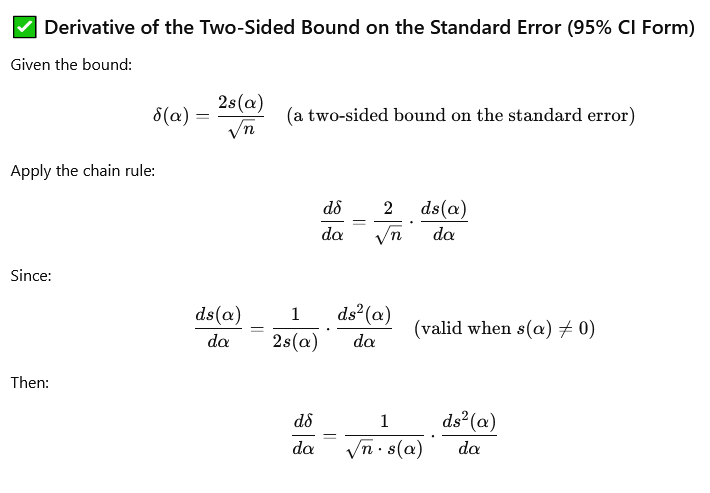

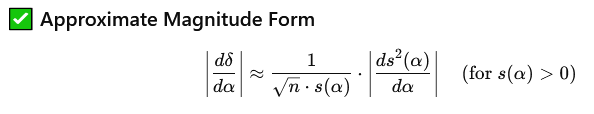

##### Loss Function and Derivative

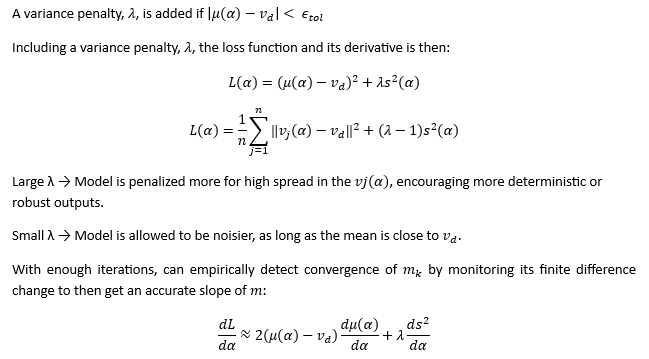